## IMDB Movie Review Sentiment Detector

**Imports & Setup**

In [30]:
import os
import re
import csv
import warnings
import joblib
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
 
import gensim
from gensim.models import Word2Vec
 
warnings.filterwarnings("ignore")
 
# Download required NLTK data
for pkg in ["stopwords", "wordnet", "punkt", "punkt_tab", "omw-1.4"]:
    nltk.download(pkg, quiet=True)

print("All imports successful.")

All imports successful.


**Load Dataset**

In [31]:
DATASET_PATH = "IMDB Dataset.csv"   

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f"Loaded local dataset: {df.shape}")
else:
    print("Local file not found — downloading via kagglehub …")
    try:
        import kagglehub
        path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
        csv_file = os.path.join(path, "IMDB Dataset.csv")
        df = pd.read_csv(csv_file)
        print(f"Downloaded and loaded: {df.shape}")
    except Exception as e:
        raise FileNotFoundError(
            "Could not find or download the dataset.\n"
            "Please place 'IMDB Dataset.csv' in the same directory as this script.\n"
            f"Error: {e}"
        )
 
print(df["sentiment"].value_counts())
print(df.head(5))

Loaded local dataset: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


**Text Preprocessing**

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
 
 
def preprocess(text: str) -> list[str]:
    text = str(text).lower()                             # lowercase
    text = re.sub(r"http\S+|www\S+", "", text)           # remove URLs
    text = re.sub(r"<.*?>", "", text)                    # remove HTML tags
    text = re.sub(r"[^a-z\s]", "", text)                 # keep only letters
    tokens = word_tokenize(text)                         # tokenization
    tokens = [t for t in tokens if t not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens]   # lemmatize
    return tokens
 
# Quick sanity check
sample = df["review"].iloc[0]
print("\n── ORIGINAL ──────────────────────────")
print(sample[:300])
print("\n── AFTER PREPROCESSING  ──────────────")
print(preprocess(sample))
 
# Apply to full dataset
print("\nPreprocessing all 50 k reviews")
df["tokens"]         = df["review"].apply(preprocess)
df["cleaned_review"] = df["tokens"].apply(lambda t: " ".join(t))
df["label"]          = df["sentiment"].map({"positive": 1, "negative": 0})
print("Preprocessing complete!")
 
# Word-count stats
df["original_length"] = df["review"].apply(lambda x: len(x.split()))
df["cleaned_length"]  = df["tokens"].apply(len)
print(f"\nAvg words BEFORE cleaning : {df['original_length'].mean():.0f}")
print(f"Avg words AFTER  cleaning : {df['cleaned_length'].mean():.0f}")
print(f"Words removed on average  : {(df['original_length'] - df['cleaned_length']).mean():.0f}")
 


── ORIGINAL ──────────────────────────
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Tru

── AFTER PREPROCESSING  ──────────────
['one', 'reviewer', 'mentioned', 'watching', 'oz', 'episode', 'youll', 'hooked', 'right', 'exactly', 'happened', 'methe', 'first', 'thing', 'struck', 'oz', 'brutality', 'unflinching', 'scene', 'violence', 'set', 'right', 'word', 'go', 'trust', 'show', 'faint', 'hearted', 'timid', 'show', 'pull', 'punch', 'regard', 'drug', 'sex', 'violence', 'hardcore', 'classic', 'use', 'wordit', 'called', 'oz', 'nickname', 'given', 'oswald', 'maximum', 'security', 'state', 'penitentary', 'focus', 'mainly', 'emerald', 'city', 'experimental', 'section', 'prison', 'cell', 'glass', 'front', 'face', 'inwards', 'privacy', 'high', 'ag

**Train / Test Split (80 / 20)**

In [33]:
X_raw   = df["cleaned_review"]
y       = df["label"]
tokens  = df["tokens"]   # used for Word2Vec
 
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)
train_tokens = tokens[X_train_raw.index]
test_tokens  = tokens[X_test_raw.index]
 
print(f"Training samples : {len(X_train_raw):,}")
print(f"Test samples     : {len(X_test_raw):,}")
 

Training samples : 40,000
Test samples     : 10,000


**Feature Extraction — Method 1: TF-IDF (with n-grams)**

In [34]:
tfidf = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True
)
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)
print(f"TF-IDF matrix: {X_train_tfidf.shape}")

TF-IDF matrix: (40000, 20000)


**Feature Extraction — Method 2: Word2Vec (sentence embedding)**

In [35]:
w2v_model = Word2Vec(
    sentences=list(train_tokens),
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=5,
    seed=42
)

def review_to_vec(tokens: list[str], model: Word2Vec) -> np.ndarray: # Average Word2Vec vectors for all known tokens in a review.
    vecs = [model.wv[t] for t in tokens if t in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)
 
 
X_train_w2v = np.vstack([review_to_vec(t, w2v_model) for t in train_tokens])
X_test_w2v  = np.vstack([review_to_vec(t, w2v_model) for t in test_tokens])
print(f"Word2Vec feature matrix: {X_train_w2v.shape}")
 

Word2Vec feature matrix: (40000, 100)


**Model Training & Evaluation**


In [36]:
# Fit model, evaluate on test set, print full classification report.
# Returns a results dict (private keys prefixed with '_').

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
 
    results = {
        "Model"         : name,
        "Classifier"    : name.split("(")[0].strip(),   # "Naive Bayes" / "SVM"
        "Features"      : name.split("(")[1].rstrip(")"),  # "TF-IDF" / "Word2Vec"
        "Accuracy"      : accuracy_score(y_test, y_pred),
        "Precision"     : precision_score(y_test, y_pred, zero_division=0),
        "Recall"        : recall_score(y_test, y_pred, zero_division=0),
        "F1-Score"      : f1_score(y_test, y_pred, zero_division=0),
        "_model"        : model,
        "_y_pred"       : y_pred,
    }
    print(f"{'-'*60}")
    print(f"  {name}")
    print(f"{'-'*60}")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"],
                                zero_division=0))
    return results

all_results = []

**1. Naive Bayes   + TF-IDF**

In [ ]:
# MultinomialNB requires non-negative features; TF-IDF values satisfy this.

print("Training: Naive Bayes + TF-IDF")
nb_tfidf = evaluate_model(
    "Naive Bayes (TF-IDF)",
    MultinomialNB(alpha=0.1),
    X_train_tfidf, X_test_tfidf, y_train, y_test
)
all_results.append(nb_tfidf)

Training: Naive Bayes + TF-IDF
------------------------------------------------------------
  Naive Bayes (TF-IDF)
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      5000
    Positive       0.86      0.89      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



**2. Naive Bayes + Word2Vec**

In [38]:
print("Training: Naive Bayes + Word2Vec")
nb_w2v = evaluate_model(
    "Naive Bayes (Word2Vec)",
    GaussianNB(),
    X_train_w2v, X_test_w2v, y_train, y_test
)
all_results.append(nb_w2v)

Training: Naive Bayes + Word2Vec
------------------------------------------------------------
  Naive Bayes (Word2Vec)
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.76      0.75      0.75      5000
    Positive       0.75      0.76      0.76      5000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



**3. Linear SVM + TF-IDF**

In [39]:
print("Training: SVM + TF-IDF")
svm_tfidf = evaluate_model(
    "SVM (TF-IDF)",
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test
)
all_results.append(svm_tfidf)

Training: SVM + TF-IDF
------------------------------------------------------------
  SVM (TF-IDF)
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90      5000
    Positive       0.89      0.90      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



**4. Linear SVM + Word2Vec**

In [40]:
print("Training: SVM + Word2Vec")
svm_w2v = evaluate_model(
    "SVM (Word2Vec)",
    LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train_w2v, X_test_w2v, y_train, y_test
)
all_results.append(svm_w2v)

Training: SVM + Word2Vec
------------------------------------------------------------
  SVM (Word2Vec)
------------------------------------------------------------
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.85      5000
    Positive       0.85      0.86      0.85      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



**Comparison Table**

In [41]:
comparison_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith("_")}
    for r in all_results
])
 
# Full detail table
print("═"*75)
print("  FULL MODEL COMPARISON (sorted by F1-Score)")
print("═"*75)
display_cols = ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
sorted_df = comparison_df[display_cols].sort_values("F1-Score", ascending=False).reset_index(drop=True)
print(sorted_df.to_string(index=False, float_format="{:.4f}".format))
print("═"*75)
 
# Grouped comparison: NB vs SVM, side-by-side per feature set 
print("\n" + "═"*75)
print("  GROUPED COMPARISON: Naive Bayes  vs  SVM")
print("═"*75)
print(f"  {'Feature Set':<14}  {'Metric':<12}  {'Naive Bayes':>12}  {'SVM':>12}  {'Winner':>12}")
print(f"  {'─'*14}  {'─'*12}  {'─'*12}  {'─'*12}  {'─'*12}")
 
for feat in ["TF-IDF", "Word2Vec"]:
    nb_row  = comparison_df[comparison_df["Model"] == f"Naive Bayes ({feat})"].iloc[0]
    svm_row = comparison_df[comparison_df["Model"] == f"SVM ({feat})"].iloc[0]
 
    for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
        nb_val  = nb_row[metric]
        svm_val = svm_row[metric]
        winner  = "Naive Bayes" if nb_val >= svm_val else "SVM"
        marker  = "⬆" if nb_val >= svm_val else "⬆"
        print(f"  {feat:<14}  {metric:<12}  {nb_val:>12.4f}  {svm_val:>12.4f}  {winner:>12}")
    print()
 
print("═"*75)
best_row  = sorted_df.iloc[0]
print(f"Overall best model : {best_row['Model']}")
print(f"F1-Score           : {best_row['F1-Score']:.4f}")
print(f"Accuracy           : {best_row['Accuracy']:.4f}")

═══════════════════════════════════════════════════════════════════════════
  FULL MODEL COMPARISON (sorted by F1-Score)
═══════════════════════════════════════════════════════════════════════════
                 Model  Accuracy  Precision  Recall  F1-Score
          SVM (TF-IDF)    0.8973     0.8925  0.9034    0.8979
  Naive Bayes (TF-IDF)    0.8730     0.8621  0.8880    0.8749
        SVM (Word2Vec)    0.8532     0.8491  0.8590    0.8540
Naive Bayes (Word2Vec)    0.7561     0.7534  0.7614    0.7574
═══════════════════════════════════════════════════════════════════════════

═══════════════════════════════════════════════════════════════════════════
  GROUPED COMPARISON: Naive Bayes  vs  SVM
═══════════════════════════════════════════════════════════════════════════
  Feature Set     Metric         Naive Bayes           SVM        Winner
  ──────────────  ────────────  ────────────  ────────────  ────────────
  TF-IDF          Accuracy            0.8730        0.8973           SVM
  

**Confusion Matrices**

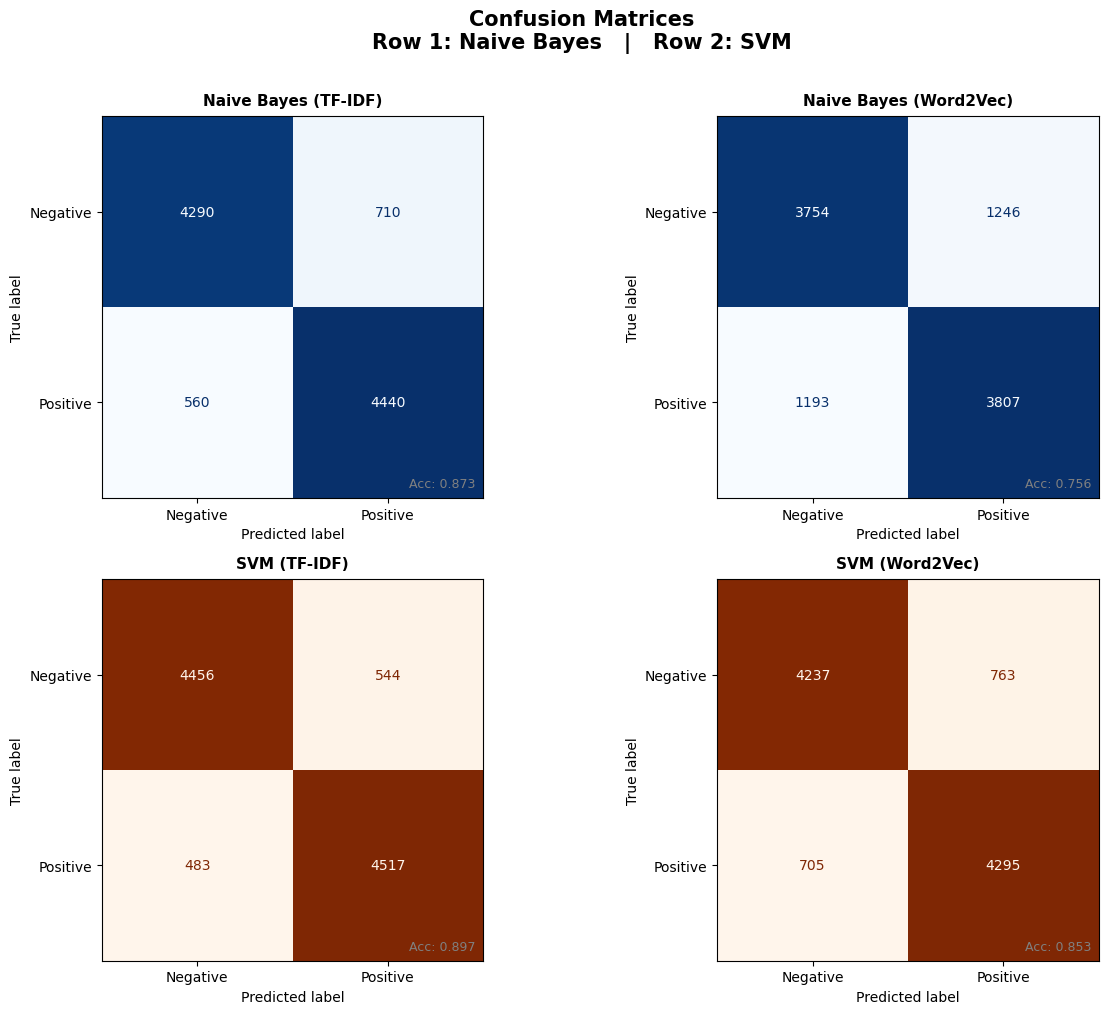

Saved confusion_matrices.png


In [42]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Confusion Matrices\nRow 1: Naive Bayes   |   Row 2: SVM",
             fontsize=15, fontweight="bold", y=1.01)
 
# Order: [NB/TF-IDF, NB/W2V, SVM/TF-IDF, SVM/W2V]
plot_order = [nb_tfidf, nb_w2v, svm_tfidf, svm_w2v]
row_labels = ["Naive Bayes", "Naive Bayes", "SVM", "SVM"]
col_labels = ["TF-IDF", "Word2Vec", "TF-IDF", "Word2Vec"]
 
for idx, (ax, res) in enumerate(zip(axes.flatten(), plot_order)):
    cm = confusion_matrix(y_test, res["_y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, colorbar=False,
              cmap="Blues" if "Naive Bayes" in res["Model"] else "Oranges")
    ax.set_title(res["Model"], fontsize=11, fontweight="bold", pad=8)
 
    # Annotate per-class accuracy in corner
    acc = accuracy_score(y_test, res["_y_pred"])
    ax.text(0.98, 0.02, f"Acc: {acc:.3f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=9, color="grey")
 
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved confusion_matrices.png")

**Grouped Bar Chart — NB vs SVM across both feature sets & metrics**

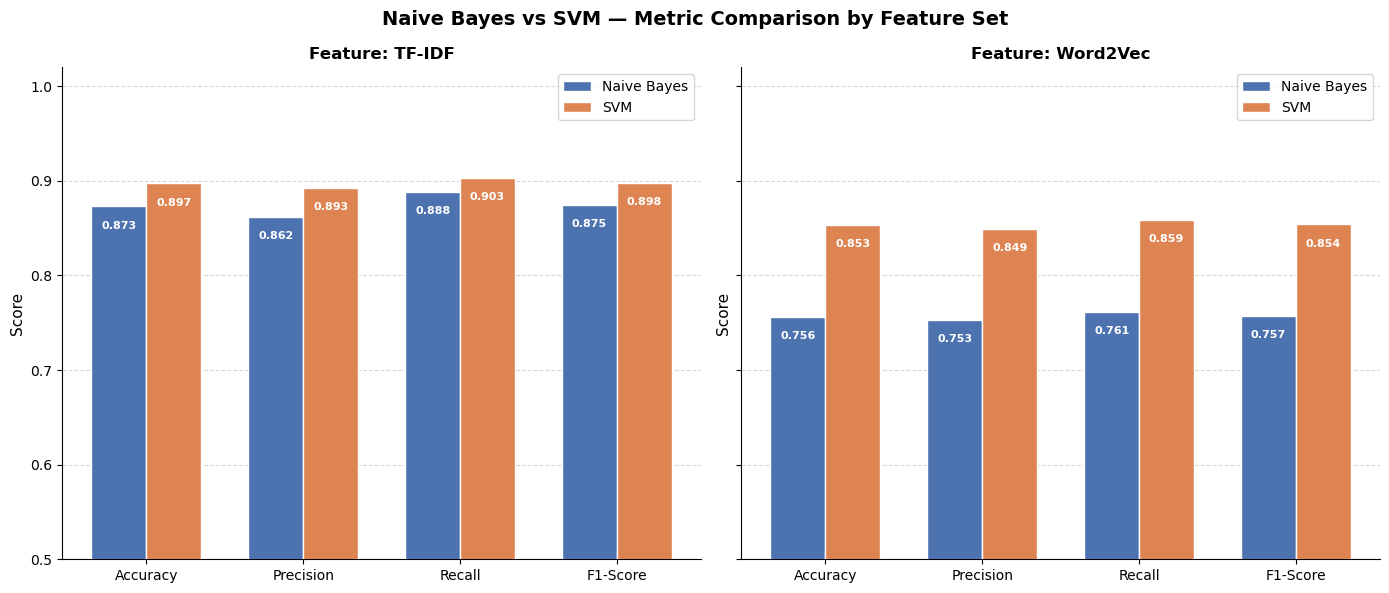

Saved model_comparison.png


In [43]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
feature_sets = ["TF-IDF", "Word2Vec"]
nb_color = "#4C72B0"   # blue  → Naive Bayes
svm_color = "#DD8452"   # orange → SVM
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Naive Bayes vs SVM — Metric Comparison by Feature Set",
             fontsize=14, fontweight="bold")
 
x = np.arange(len(metrics))
width = 0.35
 
for ax, feat in zip(axes, feature_sets):
    nb_vals  = [comparison_df.loc[comparison_df["Model"] == f"Naive Bayes ({feat})", m].values[0]
                for m in metrics]
    svm_vals = [comparison_df.loc[comparison_df["Model"] == f"SVM ({feat})", m].values[0]
                for m in metrics]
 
    bars_nb  = ax.bar(x - width/2, nb_vals,  width, label="Naive Bayes",
                      color=nb_color,  edgecolor="white", zorder=3)
    bars_svm = ax.bar(x + width/2, svm_vals, width, label="SVM",
                      color=svm_color, edgecolor="white", zorder=3)
 
    # Value labels on bars
    for bar in bars_nb + bars_svm:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() - 0.015,
                f"{bar.get_height():.3f}",
                ha="center", va="top", fontsize=8,
                color="white", fontweight="bold")
 
    ax.set_title(f"Feature: {feat}", fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=10)
    ax.set_ylim(0.5, 1.02)
    ax.set_ylabel("Score", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
 
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved model_comparison.png")

**Save Best Model + Vectorizer**

In [44]:
# Identify the best model object
best_result = max(all_results, key=lambda r: r["F1-Score"])
best_model  = best_result["_model"]
print(f"Saving best model: {best_result['Model']}")
 
joblib.dump(best_model, "best_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print(f"Best model saved  → best_model.pkl")
print(f"TF-IDF vectorizer → tfidf_vectorizer.pkl")

Saving best model: SVM (TF-IDF)
Best model saved  → best_model.pkl
TF-IDF vectorizer → tfidf_vectorizer.pkl


**Quick Inference Demo**

In [45]:
# Predict sentiment using the best model
def predict_sentiment(review_text: str) -> None:
    tokens  = preprocess(review_text)
    cleaned = " ".join(tokens)
 
    if "Word2Vec" in best_result["Model"]:
        vec = review_to_vec(tokens, w2v_model).reshape(1, -1)
    else:
        vec = tfidf.transform([cleaned])
 
    pred  = best_model.predict(vec)[0]
    label = "😊 POSITIVE" if pred == 1 else "😞 NEGATIVE"
    print(f"Review     : {review_text[:80]}{'…' if len(review_text) > 80 else ''}")
    print(f"Prediction : {label}  [{best_result['Model']}]")
 
 
predict_sentiment("This movie was absolutely fantastic! Best film I've seen this year.")
predict_sentiment("Terrible plot, bad acting, total waste of time. I want my 2 hours back.")

Review     : This movie was absolutely fantastic! Best film I've seen this year.
Prediction : 😊 POSITIVE  [SVM (TF-IDF)]
Review     : Terrible plot, bad acting, total waste of time. I want my 2 hours back.
Prediction : 😞 NEGATIVE  [SVM (TF-IDF)]
